# Задание 2. Прогноз дебита (ML)

In [1]:
import sys, os
sys.path.insert(0, '/home/jovyan/work/etl')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from io_utils import read_table, write_mart, write_mart_to_pg, pg_engine

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## Датасет

In [2]:
telemetry    = read_table('telemetry')
well_targets = read_table('well_targets')
wells        = read_table('wells')

telemetry['date'] = pd.to_datetime(telemetry['ts']).dt.date
features = (
    telemetry.groupby(['well_id', 'date'], as_index=False)
             .agg(avg_pressure=('pressure_bar', 'mean'),
                  avg_temperature=('temperature_c', 'mean'),
                  avg_power=('power_kw', 'mean'),
                  sum_pump_hours=('pump_hours', 'sum'))
)
features['date'] = pd.to_datetime(features['date'])
well_targets['target_date'] = pd.to_datetime(well_targets['target_date'])

dataset = (
    features.merge(well_targets,
                   left_on=['well_id', 'date'],
                   right_on=['well_id', 'target_date'])
            .merge(wells[['well_id', 'well_type']], on='well_id')
)
dataset = pd.get_dummies(dataset, columns=['well_type'], drop_first=True)
dataset = dataset.dropna()
print('dataset:', dataset.shape)
dataset.head()


dataset: (795, 11)


,well_id,date,avg_pressure,avg_temperature,avg_power,sum_pump_hours,target_id,target_date,daily_oil_tons,well_type_mixed,well_type_oil
0,1,2025-01-01,171.547083,71.530000,506.838333,17.03,1,2025-01-01,79.58,False,True
1,1,2025-01-02,172.996667,72.038333,494.916250,17.89,9,2025-01-02,84.56,False,True
2,1,2025-01-03,173.785000,74.367917,498.984583,18.21,18,2025-01-03,54.36,False,True
3,1,2025-01-04,174.071667,72.592500,503.523333,18.03,27,2025-01-04,92.42,False,True
4,1,2025-01-05,175.242083,73.060417,505.595833,16.91,36,2025-01-05,81.35,False,True


## Train/test

In [3]:
feature_cols = ['avg_pressure', 'avg_temperature', 'avg_power', 'sum_pump_hours'] + \
               [c for c in dataset.columns if c.startswith('well_type_')]
X = dataset[feature_cols]
y = dataset['daily_oil_tons']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'train: {X_train.shape}  test: {X_test.shape}')


train: (636, 6)  test: (159, 6)


## Обучение

In [4]:
def score(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    mae  = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    r2   = r2_score(y_te, pred)
    print(f'{name:18s}  MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.3f}')
    return model, pred, dict(model=name, mae=mae, rmse=rmse, r2=r2)

lr_model, lr_pred, lr_metrics = score('LinearRegression',
                                      LinearRegression(),
                                      X_train, y_train, X_test, y_test)
rf_model, rf_pred, rf_metrics = score('RandomForest',
                                      RandomForestRegressor(n_estimators=200,
                                                            max_depth=10,
                                                            random_state=42,
                                                            n_jobs=-1),
                                      X_train, y_train, X_test, y_test)

metrics_df = pd.DataFrame([lr_metrics, rf_metrics])
metrics_df


LinearRegression    MAE=12.10  RMSE=15.63  R²=0.828
RandomForest        MAE=11.22  RMSE=14.47  R²=0.852


,model,mae,rmse,r2
0,LinearRegression,12.100262,15.633865,0.827753
1,RandomForest,11.220700,14.467999,0.852485


## Важность признаков

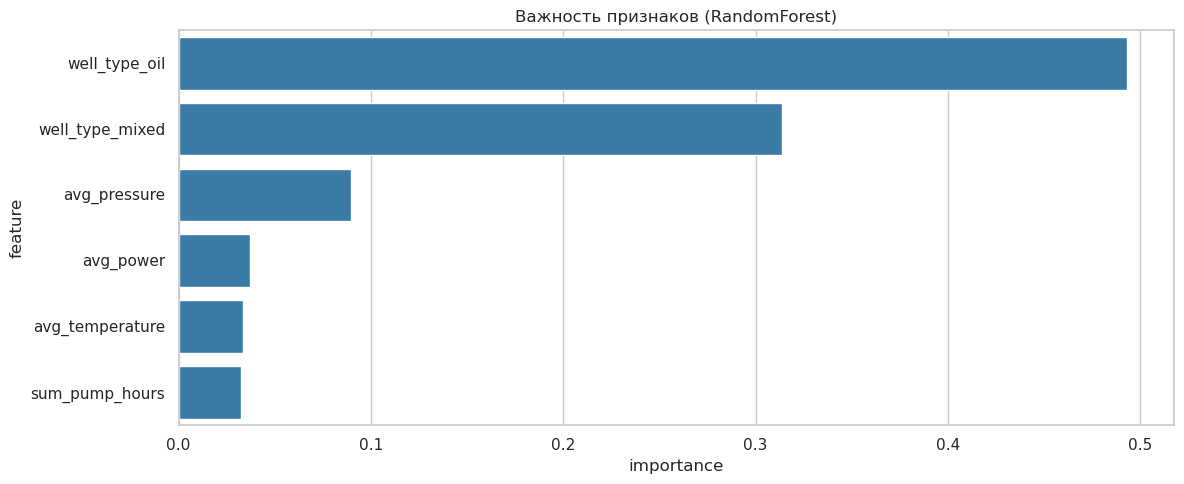

,feature,importance
5,well_type_oil,0.492931
4,well_type_mixed,0.314021
0,avg_pressure,0.089838
2,avg_power,0.037077
1,avg_temperature,0.033603
3,sum_pump_hours,0.032530


In [5]:
fi = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

sns.barplot(data=fi, x='importance', y='feature', color='#2980b9')
plt.title('Важность признаков (RandomForest)'); plt.tight_layout(); plt.show()
fi


## Actual vs Predicted

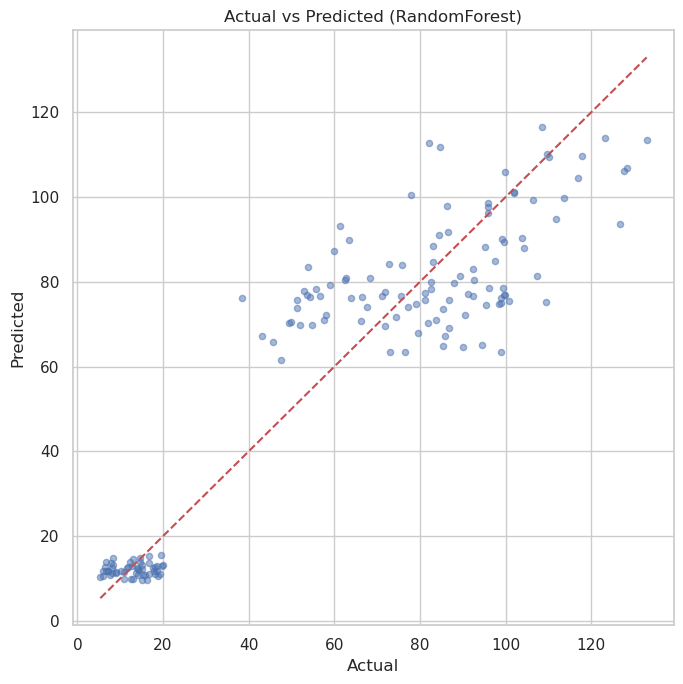

In [6]:
plot_df = X_test.copy()
plot_df['date']      = dataset.loc[X_test.index, 'target_date'].values
plot_df['well_id']   = dataset.loc[X_test.index, 'well_id'].values
plot_df['actual']    = y_test.values
plot_df['predicted'] = rf_pred
plot_df['error']     = plot_df['actual'] - plot_df['predicted']

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(plot_df['actual'], plot_df['predicted'], alpha=0.5, s=20)
lims = [plot_df[['actual', 'predicted']].min().min(),
        plot_df[['actual', 'predicted']].max().max()]
ax.plot(lims, lims, 'r--')
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
ax.set_title('Actual vs Predicted (RandomForest)')
plt.tight_layout(); plt.show()


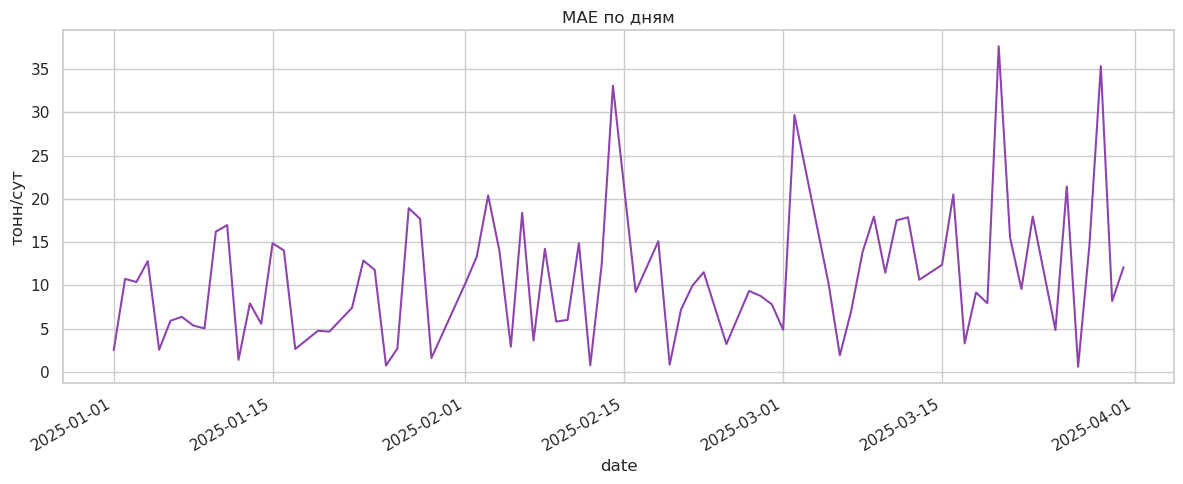

In [7]:
err_by_day = (plot_df.groupby('date', as_index=False)
                     .agg(mae=('error', lambda x: np.abs(x).mean())))
ax = err_by_day.plot(x='date', y='mae', legend=False, color='#8e44ad')
ax.set_title('MAE по дням'); ax.set_ylabel('тонн/сут'); plt.tight_layout(); plt.show()


## Сохранение

In [8]:
mart_forecast = plot_df[['date', 'well_id', 'actual', 'predicted', 'error']].copy()
mart_forecast['abs_error'] = mart_forecast['error'].abs()
uri = write_mart(mart_forecast, 'mart_forecast')
write_mart_to_pg(mart_forecast, 'mart_forecast')
write_mart_to_pg(metrics_df, 'mart_forecast_metrics')
print('Saved:', uri)
mart_forecast.head()


Saved: s3://marts/mart_forecast.parquet


,date,well_id,actual,predicted,error,abs_error
691,2025-03-15,8,6.08,10.567569,-4.487569,4.487569
662,2025-02-12,8,14.61,13.853863,0.756137,0.756137
63,2025-03-07,1,85.26,73.669721,11.590279,11.590279
531,2025-03-31,6,12.66,12.902717,-0.242717,0.242717
66,2025-03-10,1,86.33,97.946612,-11.616612,11.616612
